# Business Analytics Final Project
## Sample Superstore — Full Analysis Notebook
### Phase 2: Data Profiling & EDA | Phase 3: Business Questions

---

| | |
|---|---|
| **Members:** | Neil Francis E. Gabisay |
| | Keanu Riel Ensomo |
| **Group:** | Group 2 — IT 5101N |
| **Schedule:** | T-TH 12:30 – 3:00pm |
| **Dataset:** | Sample Superstore (samplesuperstore.csv) |
| **Domain:** | Retail / E-Commerce |
| **Records:** | 10,194 rows × 21 columns |


---
# Phase 2: Data Profiling & Exploratory Data Analysis (EDA)


## Import Libraries
We import all the libraries needed for data wrangling, statistics, and visualization.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

print('All libraries imported successfully.')


All libraries imported successfully.


## Data Loading & Initial Inspection
We load the CSV file and inspect its shape, column names, data types, and basic statistics.


In [2]:
df = pd.read_csv('samplesuperstore.csv')

print(f'Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}')
print()
print('Column Names:')
print(df.columns.tolist())


Rows: 10,194  |  Columns: 21

Column Names:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country/Region', 'City', 'State/Province', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


In [3]:
print('Data Types:')
print(df.dtypes)


Data Types:
Row ID              int64
Order ID              str
Order Date            str
Ship Date             str
Ship Mode             str
Customer ID           str
Customer Name         str
Segment               str
Country/Region        str
City                  str
State/Province        str
Postal Code           str
Region                str
Product ID            str
Category              str
Sub-Category          str
Product Name          str
Sales             float64
Quantity            int64
Discount          float64
Profit            float64
dtype: object


In [4]:
print('Dataset Info:')
df.info()


Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  str    
 2   Order Date      10194 non-null  str    
 3   Ship Date       10194 non-null  str    
 4   Ship Mode       10194 non-null  str    
 5   Customer ID     10194 non-null  str    
 6   Customer Name   10194 non-null  str    
 7   Segment         10194 non-null  str    
 8   Country/Region  10194 non-null  str    
 9   City            10194 non-null  str    
 10  State/Province  10194 non-null  str    
 11  Postal Code     10194 non-null  str    
 12  Region          10194 non-null  str    
 13  Product ID      10194 non-null  str    
 14  Category        10194 non-null  str    
 15  Sub-Category    10194 non-null  str    
 16  Product Name    10194 non-null  str    
 17  Sales           10194 non-nu

In [5]:
print('Descriptive Statistics:')
df.describe().round(2)


Descriptive Statistics:


,Row ID,Sales,Quantity,Discount,Profit
count,10194.00,10194.00,10194.00,10194.00,10194.00
mean,5097.50,228.23,3.79,0.16,28.67
std,2942.90,619.91,2.23,0.21,232.47
min,1.00,0.44,1.00,0.00,-6599.98
25%,2549.25,17.22,2.00,0.00,1.76
50%,5097.50,53.91,3.00,0.20,8.69
75%,7645.75,209.50,5.00,0.20,29.30
max,10194.00,22638.48,14.00,0.80,8399.98


In [6]:
print('First 5 Rows:')
df.head()


First 5 Rows:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,1/3/2023,1/7/2023,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,1/5/2023,1/12/2023,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


## Data Type Conversion
Order Date and Ship Date are stored as strings. We convert them to datetime and create useful derived columns.


In [7]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date']  = pd.to_datetime(df['Ship Date'])

df['Order Year']      = df['Order Date'].dt.year
df['Order Month']     = df['Order Date'].dt.month
df['Order YearMonth'] = df['Order Date'].dt.to_period('M')
df['Shipping Days']   = (df['Ship Date'] - df['Order Date']).dt.days

print('Date columns converted successfully.')
print(f"Date range: {df['Order Date'].min().date()} to {df['Order Date'].max().date()}")
print()
df[['Order Date', 'Ship Date', 'Order Year', 'Order Month', 'Shipping Days']].head()


Date columns converted successfully.
Date range: 2023-01-03 to 2026-12-30



,Order Date,Ship Date,Order Year,Order Month,Shipping Days
0,2023-01-03,2023-01-07,2023,1,4
1,2023-01-04,2023-01-08,2023,1,4
2,2023-01-04,2023-01-08,2023,1,4
3,2023-01-04,2023-01-08,2023,1,4
4,2023-01-05,2023-01-12,2023,1,7


## Missing Value Analysis
We check every column for missing values and decide whether to drop, impute, or flag them.


In [8]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing Count', ascending=False)

print('Missing Value Report:')
print(missing_df)
print()
print(f'Total missing values: {missing.sum()}')
print('No imputation or dropping required — dataset is complete.')


Missing Value Report:
                 Missing Count  Missing %
Row ID                       0        0.0
Order ID                     0        0.0
Order Date                   0        0.0
Ship Date                    0        0.0
Ship Mode                    0        0.0
Customer ID                  0        0.0
Customer Name                0        0.0
Segment                      0        0.0
Country/Region               0        0.0
City                         0        0.0
State/Province               0        0.0
Postal Code                  0        0.0
Region                       0        0.0
Product ID                   0        0.0
Category                     0        0.0
Sub-Category                 0        0.0
Product Name                 0        0.0
Sales                        0        0.0
Quantity                     0        0.0
Discount                     0        0.0
Profit                       0        0.0
Order Year                   0        0.0
Order Month 

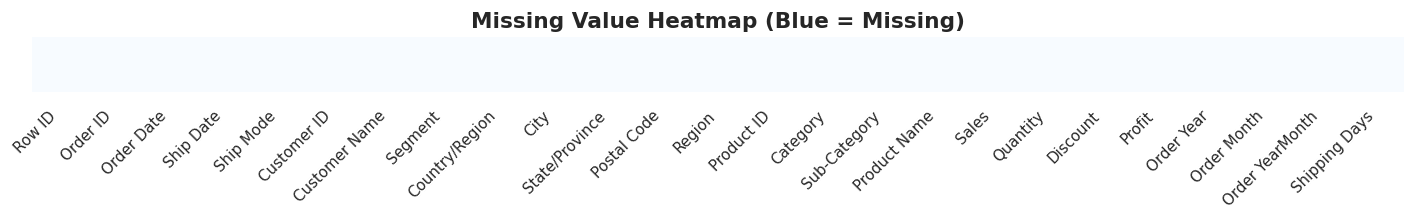

In [9]:
fig, ax = plt.subplots(figsize=(12, 2))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, ax=ax, cmap='Blues')
ax.set_title('Missing Value Heatmap (Blue = Missing)', fontsize=13, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.show()


## Duplicate Check
We check for fully duplicated rows that could skew our analysis.


In [10]:
dupes = df.duplicated().sum()
print(f'Duplicate rows: {dupes}')
if dupes == 0:
    print('No duplicate rows found. Dataset is clean.')
else:
    df = df.drop_duplicates()
    print(f'{dupes} duplicate rows removed. New shape: {df.shape}')


Duplicate rows: 0
No duplicate rows found. Dataset is clean.


## Outlier Detection — IQR Method
We use the Interquartile Range (IQR) method to detect outliers in Sales, Profit, Quantity, and Discount.

**IQR Rule:** A value is flagged as an outlier if it falls below `Q1 − 1.5×IQR` or above `Q3 + 1.5×IQR`.


In [11]:
numeric_cols = ['Sales', 'Profit', 'Quantity', 'Discount']

outlier_summary = []
for col in numeric_cols:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outlier_summary.append({
        'Column': col,
        'Q1': round(Q1, 2),
        'Q3': round(Q3, 2),
        'IQR': round(IQR, 2),
        'Lower Fence': round(lower, 2),
        'Upper Fence': round(upper, 2),
        'Outlier Count': len(outliers),
        'Outlier %': round(len(outliers)/len(df)*100, 2)
    })

outlier_df = pd.DataFrame(outlier_summary)
print('Outlier Detection Report (IQR Method):')
outlier_df


Outlier Detection Report (IQR Method):


,Column,Q1,Q3,IQR,Lower Fence,Upper Fence,Outlier Count,Outlier %
0,Sales,17.22,209.5,192.28,-271.20,497.92,1183,11.60
1,Profit,1.76,29.3,27.54,-39.54,70.60,1913,18.77
2,Quantity,2.00,5.0,3.00,-2.50,9.50,175,1.72
3,Discount,0.00,0.2,0.20,-0.30,0.50,874,8.57


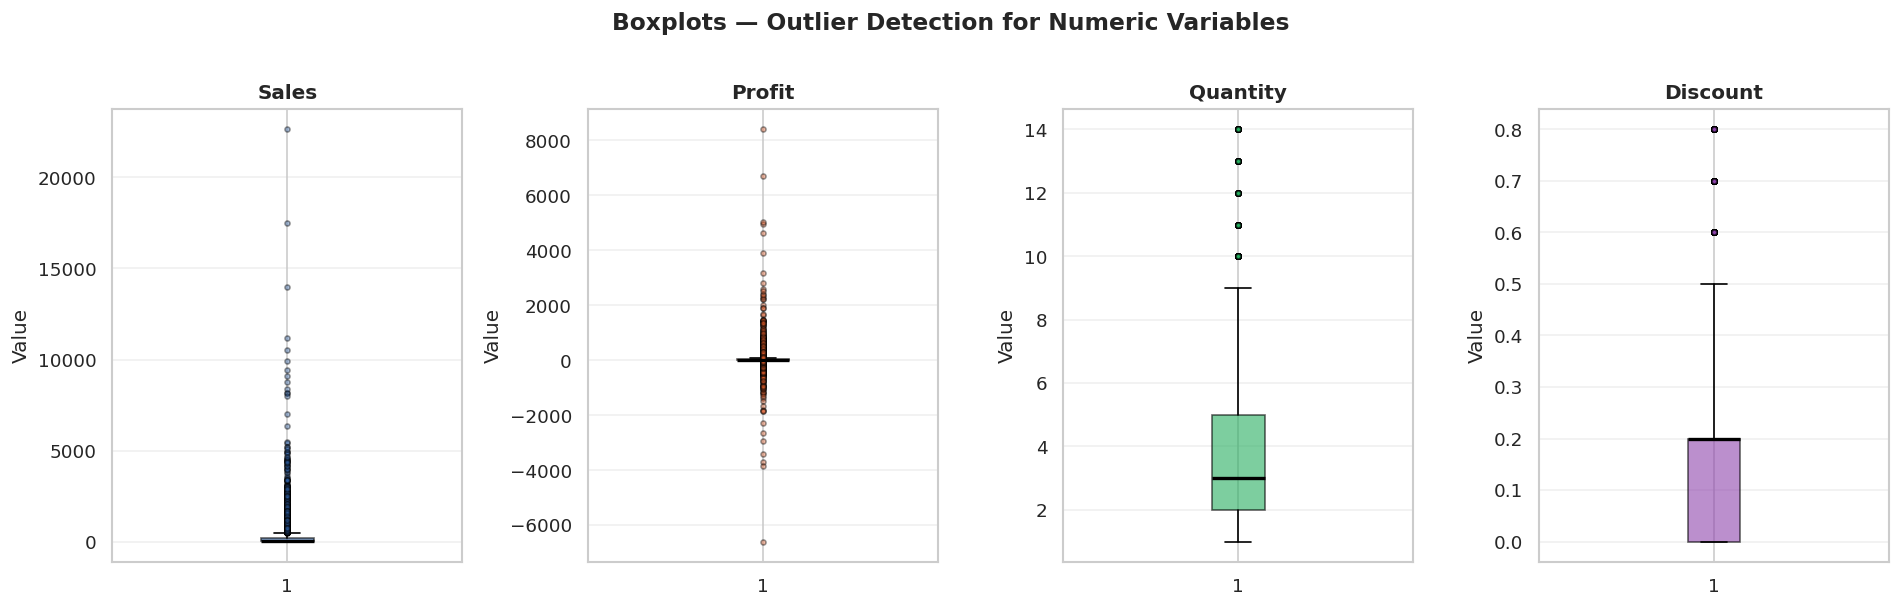

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
colors = ['#2E5FA3', '#E05C2A', '#27AE60', '#8E44AD']

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor=colors[i], alpha=0.6),
                    medianprops=dict(color='black', linewidth=2),
                    flierprops=dict(marker='o', markerfacecolor=colors[i], markersize=3, alpha=0.4))
    axes[i].set_title(col, fontweight='bold', fontsize=12)
    axes[i].set_ylabel('Value')
    axes[i].grid(axis='y', alpha=0.3)

fig.suptitle('Boxplots — Outlier Detection for Numeric Variables', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## Distribution Analysis
We plot histograms with KDE curves for all four numeric variables to understand the shape and skewness of their distributions.


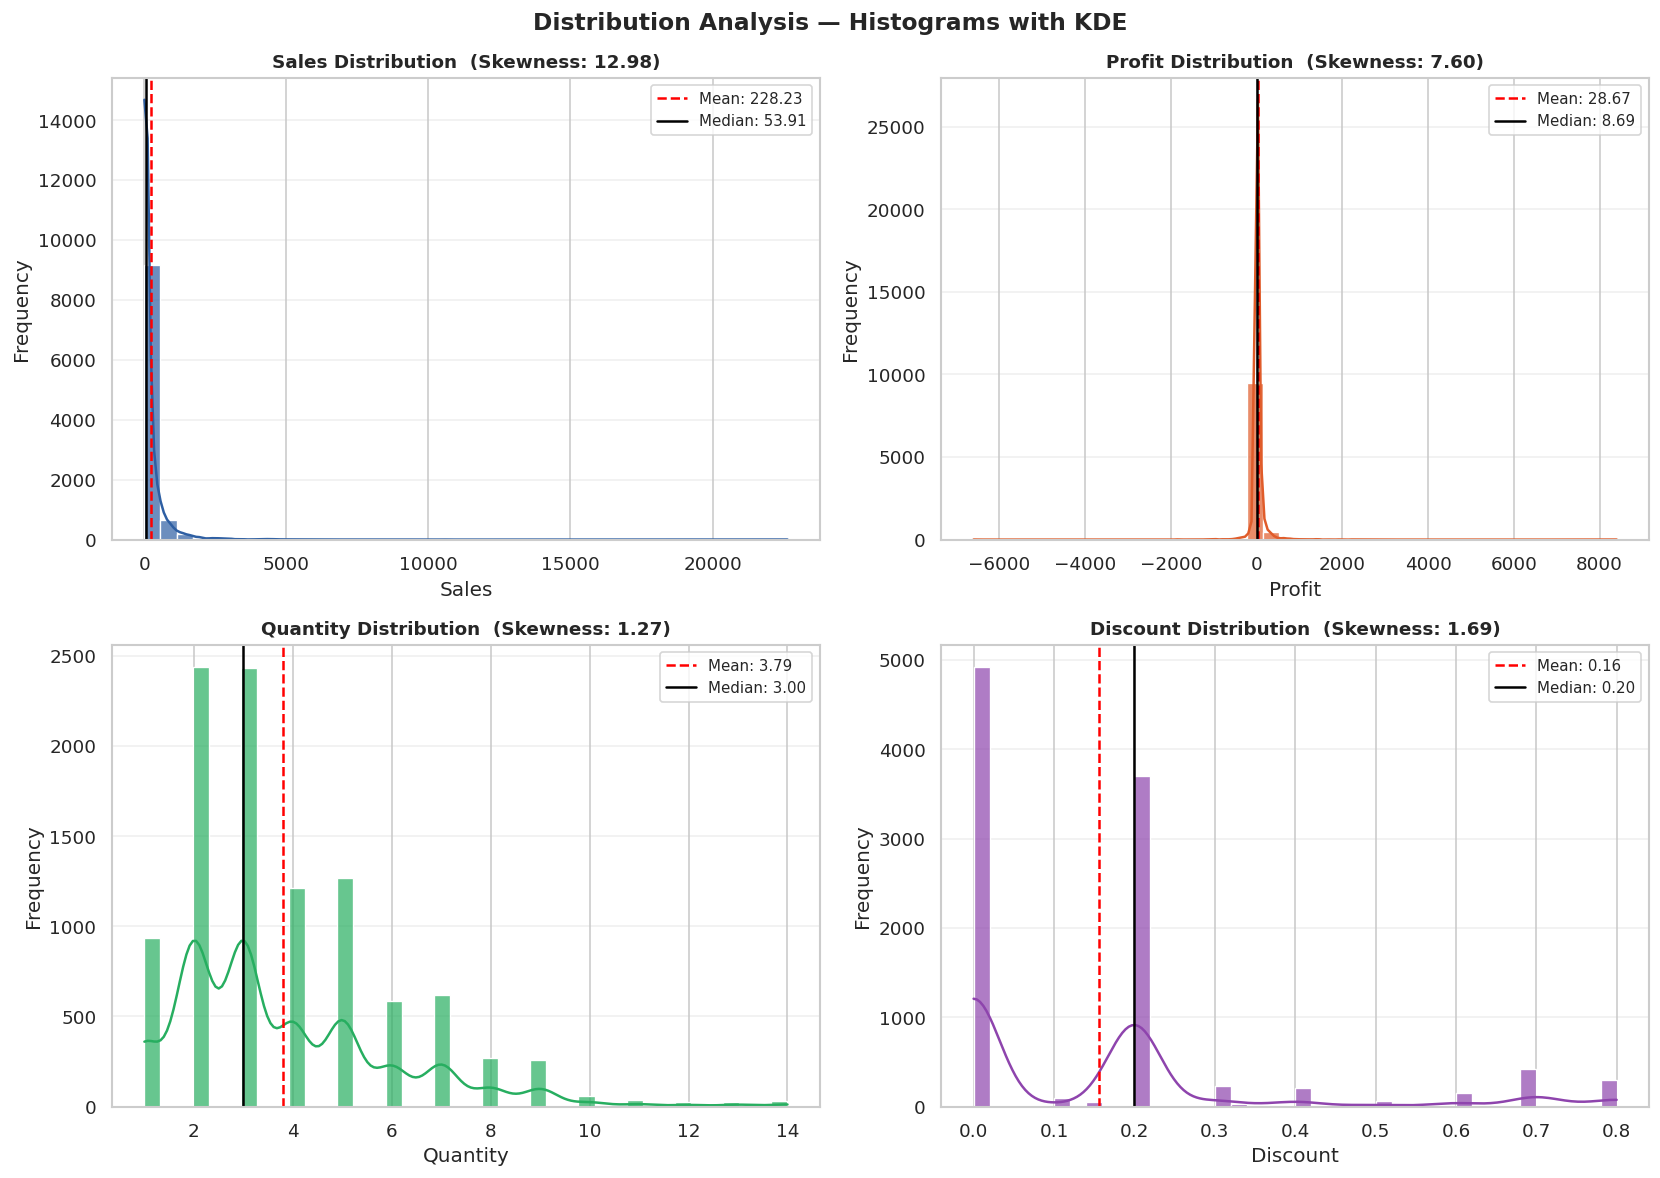

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
colors = ['#2E5FA3', '#E05C2A', '#27AE60', '#8E44AD']

for i, col in enumerate(numeric_cols):
    skew_val = df[col].skew()
    sns.histplot(df[col], ax=axes[i], kde=True, color=colors[i], bins=40, alpha=0.7)
    axes[i].axvline(df[col].mean(),   color='red',   linestyle='--', linewidth=1.5, label=f'Mean: {df[col].mean():.2f}')
    axes[i].axvline(df[col].median(), color='black', linestyle='-',  linewidth=1.5, label=f'Median: {df[col].median():.2f}')
    axes[i].set_title(f'{col} Distribution  (Skewness: {skew_val:.2f})', fontweight='bold', fontsize=11)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[i].legend(fontsize=9)
    axes[i].grid(axis='y', alpha=0.3)

fig.suptitle('Distribution Analysis — Histograms with KDE', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## Correlation Matrix
We compute Pearson correlation between all numeric variables to identify relationships — especially with Profit.


In [14]:
corr_cols = ['Sales', 'Profit', 'Quantity', 'Discount', 'Shipping Days']
corr_matrix = df[corr_cols].corr().round(3)

print('Correlation Matrix:')
print(corr_matrix)


Correlation Matrix:
               Sales  Profit  Quantity  Discount  Shipping Days
Sales          1.000   0.481     0.198    -0.028         -0.007
Profit         0.481   1.000     0.066    -0.219         -0.004
Quantity       0.198   0.066     1.000     0.007          0.021
Discount      -0.028  -0.219     0.007     1.000         -0.002
Shipping Days -0.007  -0.004     0.021    -0.002          1.000


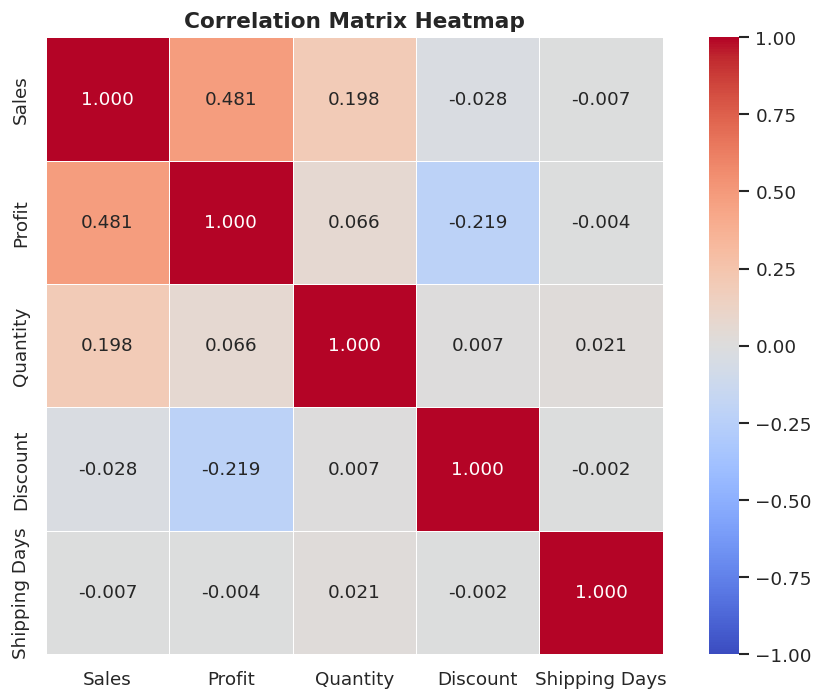

In [15]:
fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True, fmt='.3f', cmap='coolwarm',
    center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5,
    ax=ax, annot_kws={'size': 11}
)
ax.set_title('Correlation Matrix Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## EDA Summary — Key Observations

Based on the exploratory data analysis, here are the five key observations from the dataset:

**1. Dataset is Complete and Clean**  
All 21 columns across 10,194 records contain zero missing values and zero duplicate rows. No data cleaning was required — analysis proceeds on the full dataset.

**2. Sales and Profit are Severely Right-Skewed**  
The median Sales ($53.91) is less than a quarter of the mean ($228.23), meaning most transactions are small while a few very large orders pull the average upward. The same pattern applies to Profit (median $8.69 vs mean $28.67).

**3. Negative Profit is a Structural Problem**  
Profit ranges from −$6,600 to +$8,400. With 1,913 records (18.77%) flagged as profit outliers, loss-making transactions follow a pattern tied to high discount rates — not random data errors.

**4. Discount is the Strongest Negative Driver of Profit**  
The correlation between Discount and Profit is −0.219. Critically, Discount and Sales have near-zero correlation (−0.028), meaning discounting does not meaningfully increase revenue while it clearly reduces profit.

**5. Quantity Has Minimal Impact on Profitability**  
Quantity shows only a +0.066 correlation with Profit. Product type and discount level — not order size — are the primary drivers of whether a transaction is profitable.


---
# Phase 3: Answering the Business Questions


---
## Q1 — Descriptive Statistics
**Question:** What are the average, median, spread, and distribution of Sales, Profit, Quantity, and Discount?

We summarize all key numeric variables using measures of central tendency, spread, and shape.


In [16]:
def descriptive_stats(df, cols):
    rows = []
    for col in cols:
        s = df[col]
        Q1  = s.quantile(0.25)
        Q3  = s.quantile(0.75)
        rows.append({
            'Variable':  col,
            'Mean':      round(s.mean(), 2),
            'Median':    round(s.median(), 2),
            'Mode':      round(s.mode()[0], 2),
            'Std Dev':   round(s.std(), 2),
            'Variance':  round(s.var(), 2),
            'Min':       round(s.min(), 2),
            'Max':       round(s.max(), 2),
            'Range':     round(s.max() - s.min(), 2),
            'IQR':       round(Q3 - Q1, 2),
            'Skewness':  round(s.skew(), 3)
        })
    return pd.DataFrame(rows).set_index('Variable')

stats_table = descriptive_stats(df, ['Sales', 'Profit', 'Quantity', 'Discount'])
print('Descriptive Statistics Table:')
stats_table


Descriptive Statistics Table:


,Mean,Median,Mode,Std Dev,Variance,Min,Max,Range,IQR,Skewness
Variable,,,,,,,,,,
Sales,228.23,53.91,12.96,619.91,384284.49,0.44,22638.48,22638.04,192.28,12.984
Profit,28.67,8.69,0.00,232.47,54040.03,-6599.98,8399.98,14999.95,27.54,7.605
Quantity,3.79,3.00,2.00,2.23,4.97,1.00,14.00,13.00,3.00,1.269
Discount,0.16,0.20,0.00,0.21,0.04,0.00,0.80,0.80,0.20,1.687


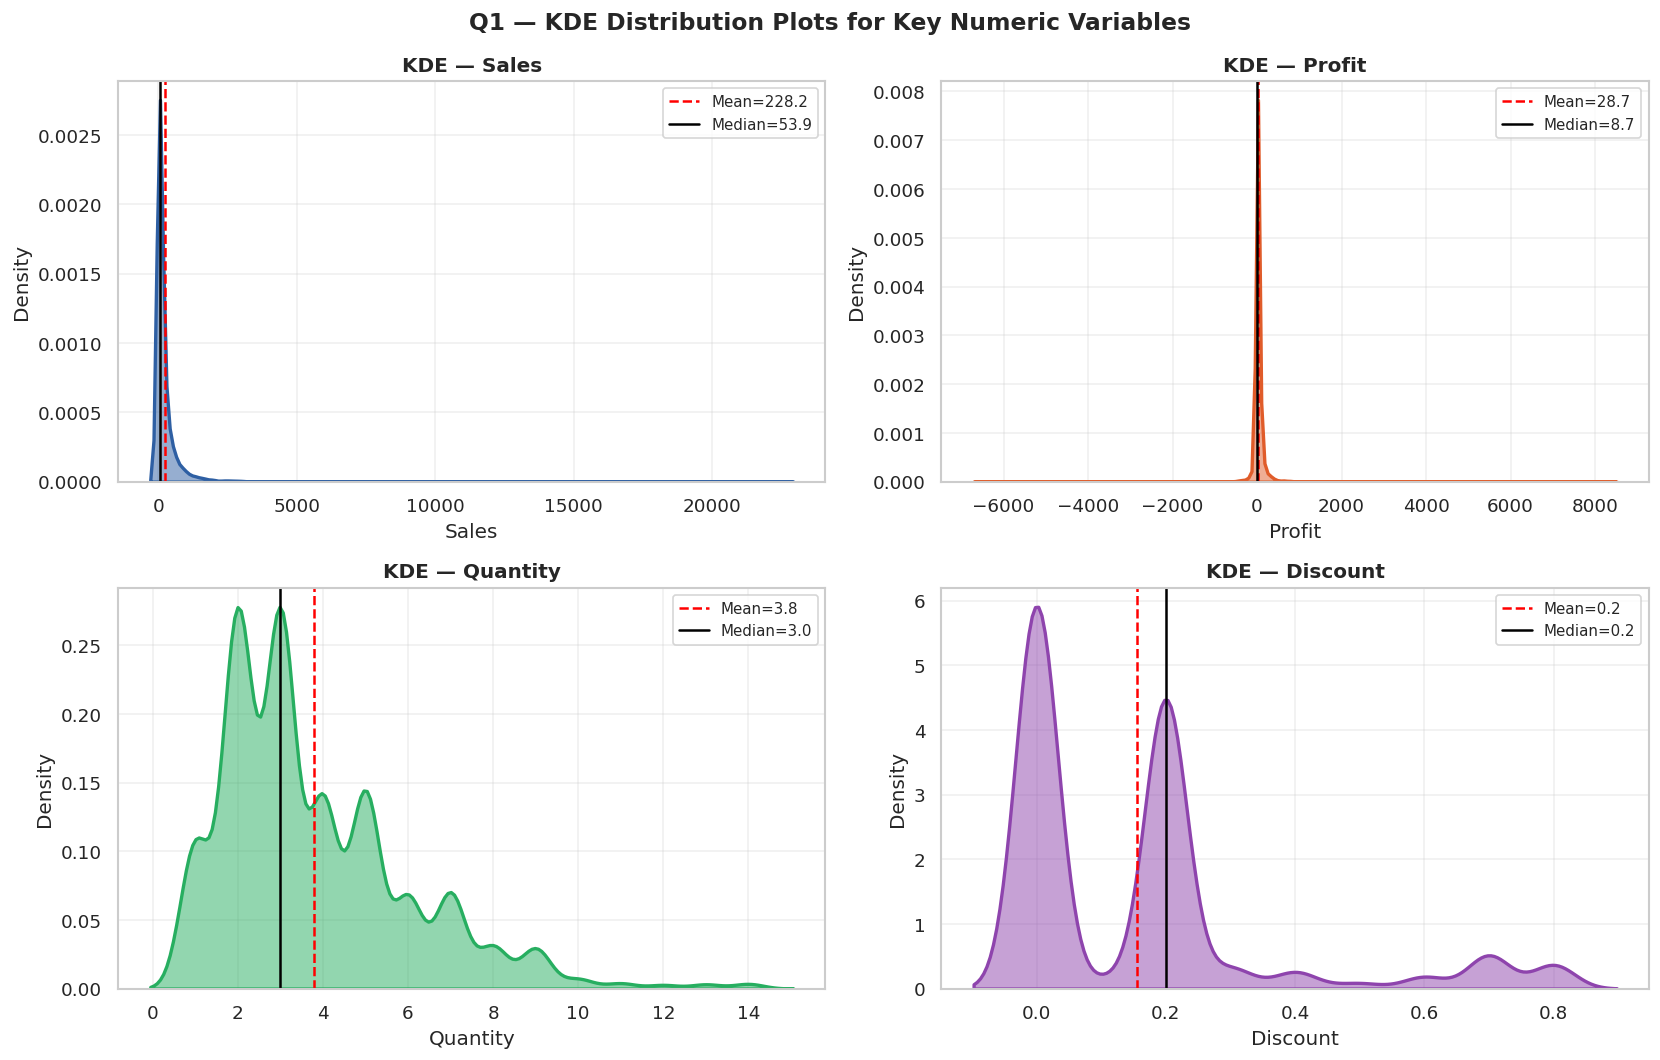

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()
colors = ['#2E5FA3', '#E05C2A', '#27AE60', '#8E44AD']

for i, col in enumerate(['Sales', 'Profit', 'Quantity', 'Discount']):
    sns.kdeplot(df[col], ax=axes[i], fill=True, color=colors[i], alpha=0.5, linewidth=2)
    axes[i].axvline(df[col].mean(),   color='red',   linestyle='--', label=f"Mean={df[col].mean():.1f}")
    axes[i].axvline(df[col].median(), color='black', linestyle='-',  label=f"Median={df[col].median():.1f}")
    axes[i].set_title(f'KDE — {col}', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=9)
    axes[i].grid(alpha=0.3)

fig.suptitle('Q1 — KDE Distribution Plots for Key Numeric Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


**Business Interpretation:**  
Sales (mean \$228, median \$54) and Profit (mean \$29, median \$9) are heavily right-skewed — most transactions are low-value but a few large orders drive the averages up. Discount is concentrated at 0% and 20%, suggesting a two-tier pricing policy. Quantity peaks at 2–3 units per order, typical for office supply purchases.


---
## Q2 — Trend Analysis
**Question:** How do monthly Sales and Profit change over time?

We aggregate Sales and Profit by month and visualize using time-series line charts to identify trends and seasonal patterns.


In [18]:
monthly = df.groupby('Order YearMonth').agg(
    Total_Sales  = ('Sales',    'sum'),
    Total_Profit = ('Profit',   'sum'),
    Order_Count  = ('Order ID', 'count')
).reset_index()

monthly['Order YearMonth'] = monthly['Order YearMonth'].astype(str)
monthly['Month_Num'] = range(len(monthly))

print(f'Monthly data spans {len(monthly)} months')
monthly.head()


Monthly data spans 48 months


,Order YearMonth,Total_Sales,Total_Profit,Order_Count,Month_Num
0,2023-01,14518.055,2539.3907,84,0
1,2023-02,4519.892,862.3084,46,1
2,2023-03,56933.909,693.4499,159,2
3,2023-04,28295.345,3488.8352,135,3
4,2023-05,26319.767,3196.3918,132,4


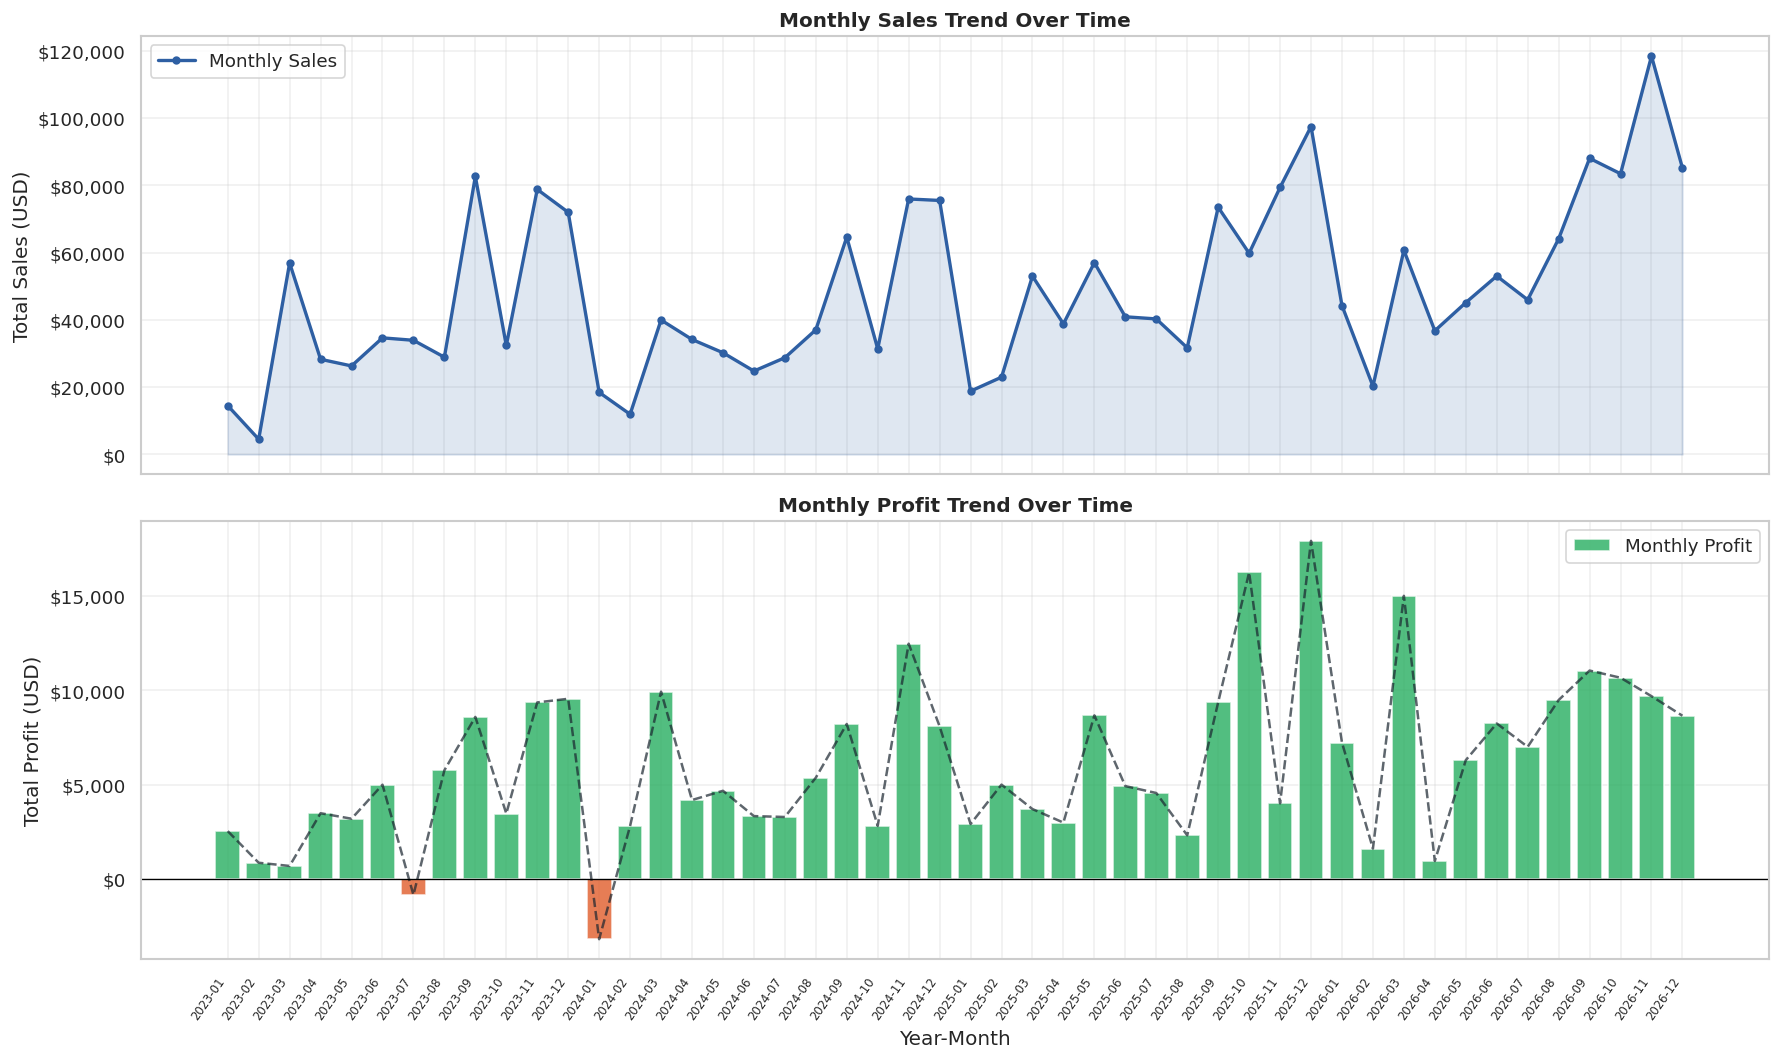

Best Sales Month:   2026-11  — $118,455
Worst Profit Month: 2024-01  — $-3,190


In [19]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 9), sharex=True)

ax1.plot(monthly['Order YearMonth'], monthly['Total_Sales'],
         color='#2E5FA3', linewidth=2, marker='o', markersize=4, label='Monthly Sales')
ax1.fill_between(monthly['Order YearMonth'], monthly['Total_Sales'], alpha=0.15, color='#2E5FA3')
ax1.set_title('Monthly Sales Trend Over Time', fontweight='bold', fontsize=12)
ax1.set_ylabel('Total Sales (USD)')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax1.grid(alpha=0.3)
ax1.legend()

profit_colors = ['#27AE60' if v >= 0 else '#E05C2A' for v in monthly['Total_Profit']]
ax2.bar(monthly['Order YearMonth'], monthly['Total_Profit'], color=profit_colors, alpha=0.8, label='Monthly Profit')
ax2.plot(monthly['Order YearMonth'], monthly['Total_Profit'],
         color='#1A252F', linewidth=1.5, linestyle='--', alpha=0.7)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_title('Monthly Profit Trend Over Time', fontweight='bold', fontsize=12)
ax2.set_ylabel('Total Profit (USD)')
ax2.set_xlabel('Year-Month')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax2.grid(alpha=0.3)
ax2.legend()

plt.xticks(rotation=55, ha='right', fontsize=7)
plt.tight_layout()
plt.show()

best_sales   = monthly.loc[monthly['Total_Sales'].idxmax()]
worst_profit = monthly.loc[monthly['Total_Profit'].idxmin()]
print(f'Best Sales Month:   {best_sales["Order YearMonth"]}  — ${best_sales["Total_Sales"]:,.0f}')
print(f'Worst Profit Month: {worst_profit["Order YearMonth"]}  — ${worst_profit["Total_Profit"]:,.0f}')


**Business Interpretation:**  
Sales show a generally upward trend with seasonal spikes in Q4 (October–December), consistent with retail holiday purchasing patterns. Profit does not always follow sales growth — some high-sales months have low or negative profit, suggesting aggressive discounting during peak periods. This is a key risk: revenue growth masking margin erosion.


---
## Q3 — Cross-Tabulation Analysis
**Question:** Which product categories perform best across different regions and customer segments?

We use pivot_table() to examine Sales and Profit across Category × Region and Category × Segment, visualized as heatmaps.


In [20]:
ct_sales = df.pivot_table(
    values='Sales', index='Category', columns='Region', aggfunc='sum'
).round(0)

ct_profit = df.pivot_table(
    values='Profit', index='Category', columns='Segment', aggfunc='sum'
).round(0)

print('Category x Region — Total Sales:')
print(ct_sales)
print()
print('Category x Segment — Total Profit:')
print(ct_profit)


Category x Region — Total Sales:
Region            Central      East     South      West
Category                                               
Furniture        164538.0  212232.0  117299.0  260680.0
Office Supplies  168217.0  211658.0  125651.0  226367.0
Technology       170416.0  267938.0  148772.0  252767.0

Category x Segment — Total Profit:
Segment          Consumer  Corporate  Home Office
Category                                         
Furniture          7544.0     7850.0       4335.0
Office Supplies   58029.0    41719.0      26275.0
Technology        70798.0    44681.0      31065.0


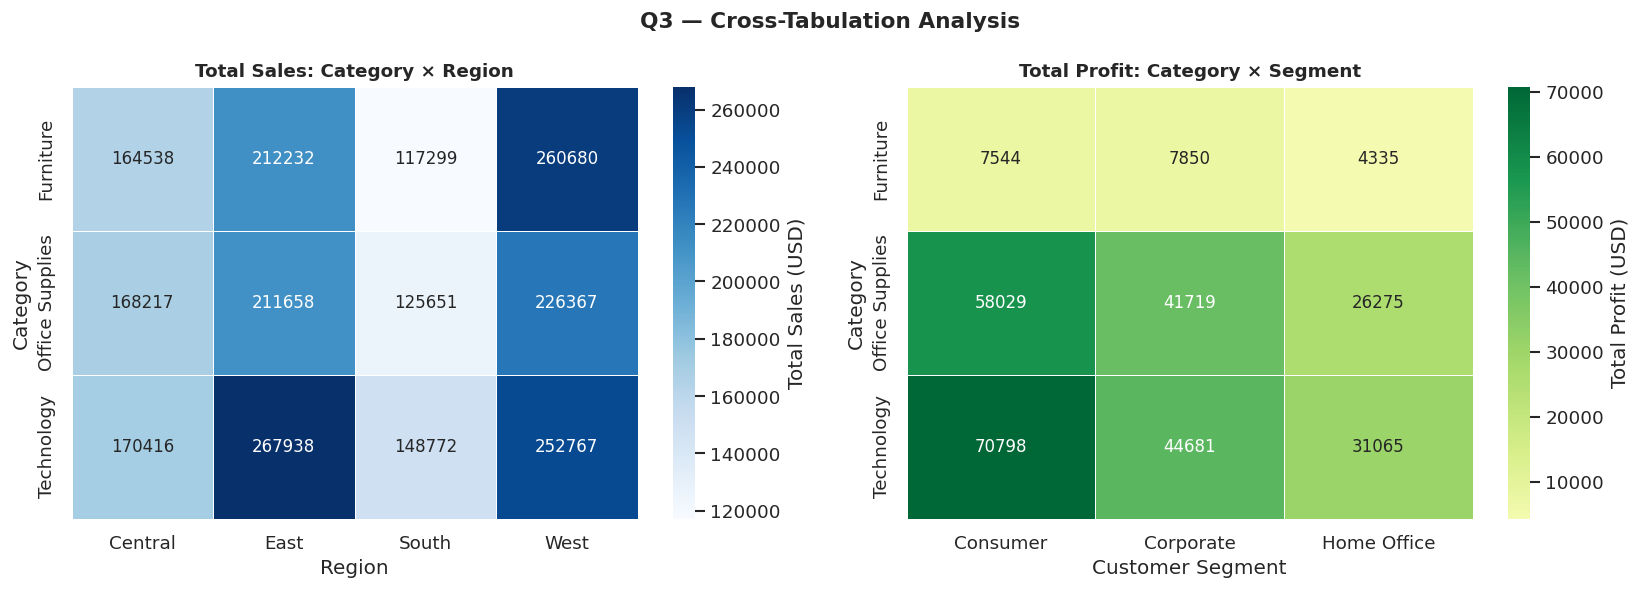

In [21]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(
    ct_sales, annot=True, fmt='.0f', cmap='Blues',
    ax=ax1, linewidths=0.5, annot_kws={'size': 10},
    cbar_kws={'label': 'Total Sales (USD)'}
)
ax1.set_title('Total Sales: Category × Region', fontweight='bold', fontsize=11)
ax1.set_xlabel('Region')
ax1.set_ylabel('Category')

sns.heatmap(
    ct_profit, annot=True, fmt='.0f', cmap='RdYlGn',
    center=0, ax=ax2, linewidths=0.5, annot_kws={'size': 10},
    cbar_kws={'label': 'Total Profit (USD)'}
)
ax2.set_title('Total Profit: Category × Segment', fontweight='bold', fontsize=11)
ax2.set_xlabel('Customer Segment')
ax2.set_ylabel('Category')

plt.suptitle('Q3 — Cross-Tabulation Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


**Business Interpretation:**  
Technology generates the highest sales across all regions, particularly in the West and East. Office Supplies is the most consistently profitable category across all customer segments. Furniture underperforms in profitability relative to its sales volume — especially in the Consumer segment — suggesting high costs or deep discounts. The Corporate segment produces the strongest profit-to-sales ratio.


---
## Q4 — Drill-Down Analysis
**Question:** How do total Sales break down from Region → State → City → Category?

We progressively decompose total sales into finer levels of detail using an interactive treemap.


In [22]:
print('Total Sales:', f"${df['Sales'].sum():,.2f}")
print()

by_region = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
print('Sales by Region:')
for r, v in by_region.items():
    print(f'  {r:<10}: ${v:>12,.2f}  ({v/df["Sales"].sum()*100:.1f}%)')
print()

by_state = df.groupby(['Region','State/Province'])['Sales'].sum().sort_values(ascending=False)
print('Top 3 States per Region:')
for region in df['Region'].unique():
    top3 = by_state[region].head(3)
    print(f'  {region}:')
    for state, val in top3.items():
        print(f'    {state:<20}: ${val:>10,.0f}')


Total Sales: $2,326,534.35

Sales by Region:
  West      : $  739,813.61  (31.8%)
  East      : $  691,828.17  (29.7%)
  Central   : $  503,170.67  (21.6%)
  South     : $  391,721.90  (16.8%)

Top 3 States per Region:
  Central:
    Texas               : $   170,188
    Illinois            : $    80,166
    Michigan            : $    76,270
  East:
    New York            : $   310,876
    Pennsylvania        : $   116,512
    Ohio                : $    78,258
  South:
    Florida             : $    89,474
    Virginia            : $    70,637
    North Carolina      : $    55,603
  West:
    California          : $   457,688
    Washington          : $   138,641
    Arizona             : $    35,282


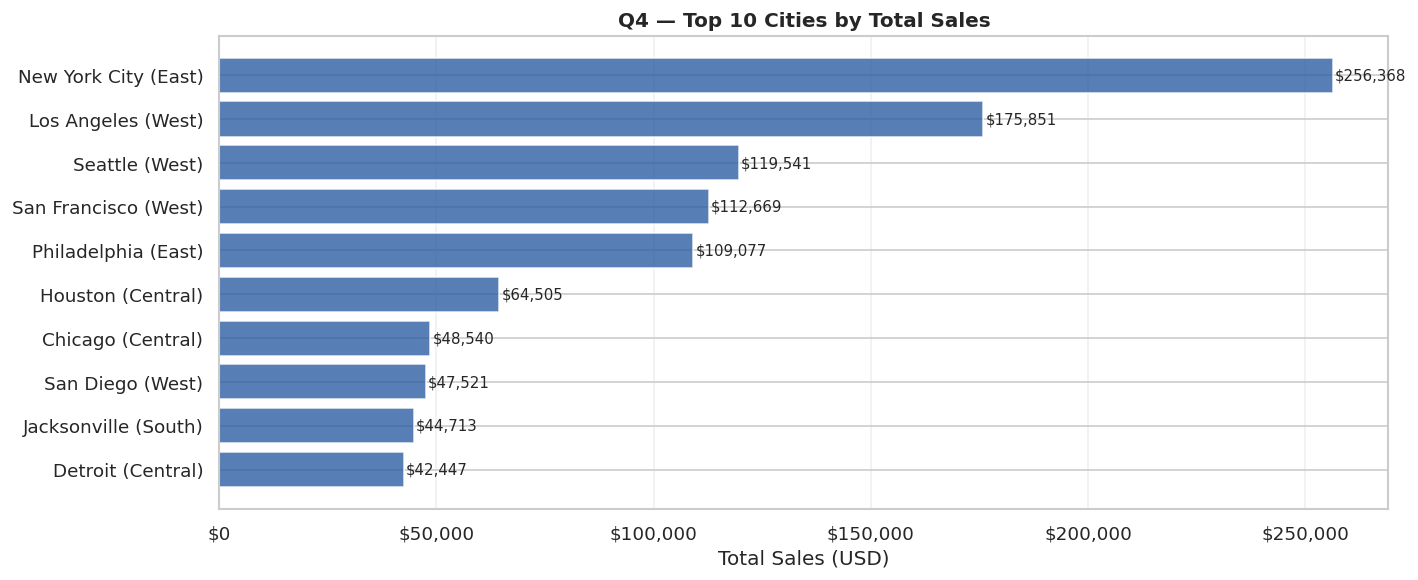

In [23]:
treemap_data = df.groupby(['Region', 'State/Province', 'Category'])['Sales'].sum().reset_index()
treemap_data.columns = ['Region', 'State', 'Category', 'Sales']
treemap_data['Sales'] = treemap_data['Sales'].round(0)

fig = px.treemap(
    treemap_data,
    path=[px.Constant('All Sales'), 'Region', 'State', 'Category'],
    values='Sales',
    color='Sales',
    color_continuous_scale='Blues',
    title='Q4 — Drill-Down: Sales from Region → State → Category',
    hover_data={'Sales': ':,.0f'}
)
fig.update_layout(margin=dict(t=50, l=10, r=10, b=10))
fig.show()

top_cities = df.groupby(['City','Region'])['Sales'].sum().sort_values(ascending=False).head(10).reset_index()

fig2, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(top_cities['City'] + ' (' + top_cities['Region'] + ')',
               top_cities['Sales'], color='#2E5FA3', alpha=0.8)
ax.set_xlabel('Total Sales (USD)')
ax.set_title('Q4 — Top 10 Cities by Total Sales', fontweight='bold', fontsize=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
for bar, val in zip(bars, top_cities['Sales']):
    ax.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
            f'${val:,.0f}', va='center', fontsize=9)
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()
plt.tight_layout()
plt.show()


**Business Interpretation:**  
The West region leads in total sales, driven primarily by California. The East follows closely with New York as the top-performing state. The Central and South regions lag significantly. At the category level, Technology dominates sales in virtually every region and state. A small number of cities (New York, Los Angeles, Seattle) account for a disproportionate share of overall revenue.


---
## Q5 — Correlation & Predictive Analysis
**Question:** Which variables are most related to Profit, and can we build a model to predict it?

We identify the strongest predictors of Profit using correlation, then build a multiple linear regression model.


In [24]:
corr_with_profit = df[['Sales', 'Quantity', 'Discount', 'Shipping Days', 'Profit']].corr()['Profit'].drop('Profit').sort_values()

print('Correlation with Profit:')
for var, corr in corr_with_profit.items():
    print(f'  {var:<15}: {corr:>+.4f}')


Correlation with Profit:
  Discount       : -0.2189
  Shipping Days  : -0.0044
  Quantity       : +0.0661
  Sales          : +0.4815


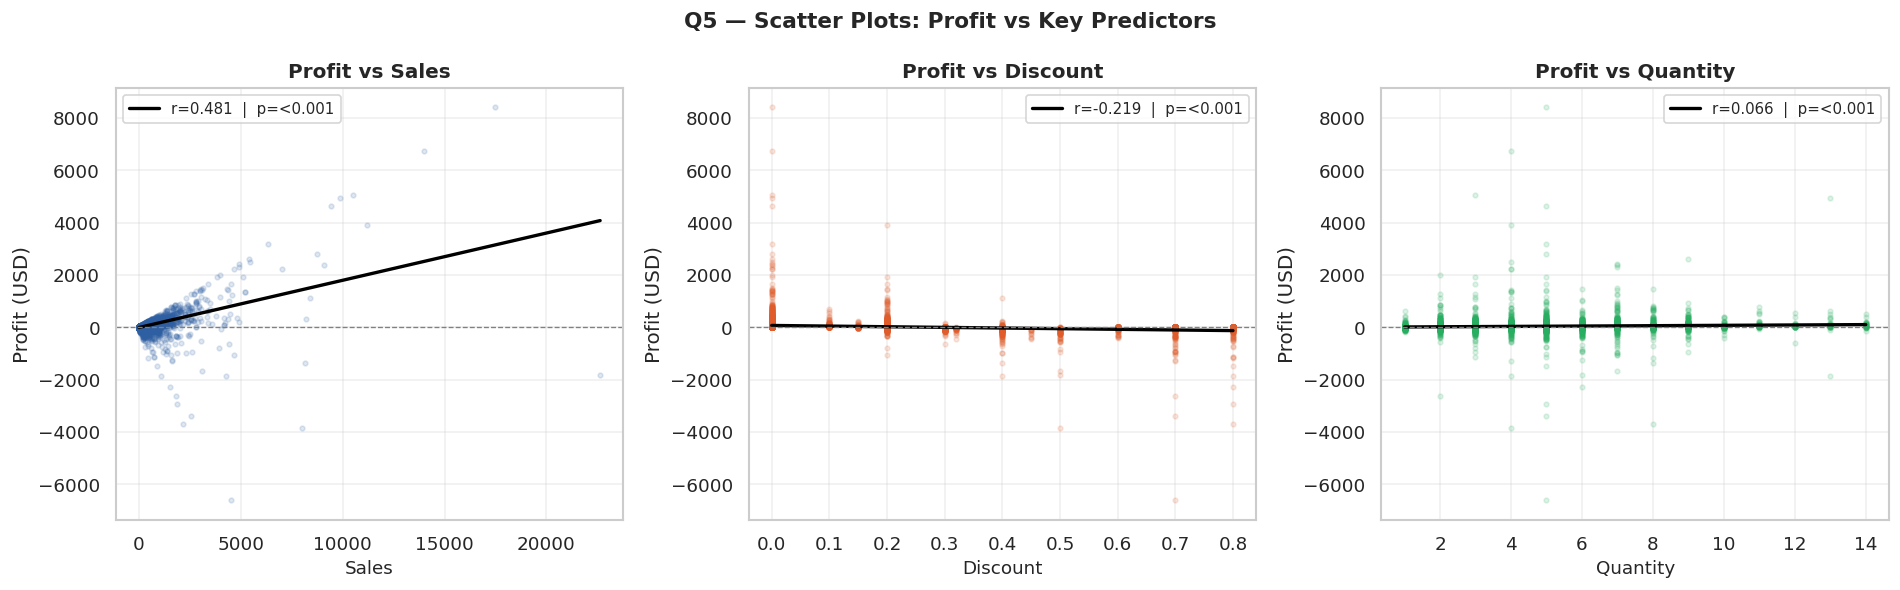

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
pairs = [('Sales', '#2E5FA3'), ('Discount', '#E05C2A'), ('Quantity', '#27AE60')]

for ax, (xvar, color) in zip(axes, pairs):
    ax.scatter(df[xvar], df['Profit'], alpha=0.15, s=8, color=color)
    m, b, r, p, _ = stats.linregress(df[xvar], df['Profit'])
    x_line = np.linspace(df[xvar].min(), df[xvar].max(), 100)
    ax.plot(x_line, m * x_line + b, color='black', linewidth=2,
            label=f'r={r:.3f}  |  p={"<0.001" if p < 0.001 else f"{p:.3f}"}')
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    ax.set_xlabel(xvar, fontsize=11)
    ax.set_ylabel('Profit (USD)')
    ax.set_title(f'Profit vs {xvar}', fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

fig.suptitle('Q5 — Scatter Plots: Profit vs Key Predictors', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [26]:
features = ['Sales', 'Quantity', 'Discount', 'Shipping Days']
X = df[features]
y = df['Profit']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

r2   = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print('Linear Regression Model Results:')
print(f'  R² Score : {r2:.4f}  ({r2*100:.1f}% of variance in Profit explained)')
print(f'  RMSE     : ${rmse:,.2f}')
print()
print('Coefficients:')
for feat, coef in zip(features, model.coef_):
    print(f'  {feat:<15}: {coef:>+.4f}')
print(f'  Intercept      : {model.intercept_:>+.4f}')

X_sm = sm.add_constant(X_train)
ols  = sm.OLS(y_train, X_sm).fit()
print()
print('OLS Summary:')
print(ols.summary().tables[1])


Linear Regression Model Results:
  R² Score : 0.3997  (40.0% of variance in Profit explained)
  RMSE     : $232.09

Coefficients:
  Sales          : +0.1212
  Quantity       : +0.5664
  Discount       : -247.2782
  Shipping Days  : -0.6558
  Intercept      : +37.6870

OLS Summary:
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            37.6870      6.567      5.739      0.000      24.814      50.560
Sales             0.1212      0.004     32.865      0.000       0.114       0.128
Quantity          0.5664      0.985      0.575      0.565      -1.365       2.497
Discount       -247.2782     10.381    -23.821      0.000    -267.627    -226.929
Shipping Days    -0.6558      1.224     -0.536      0.592      -3.055       1.744


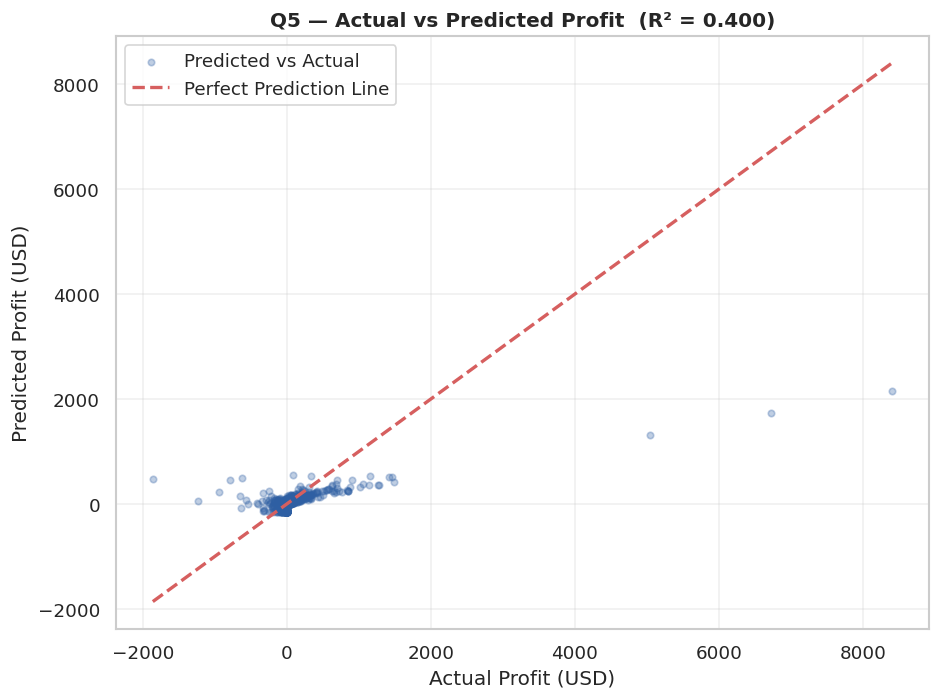

In [27]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_test, y_pred, alpha=0.3, s=15, color='#2E5FA3', label='Predicted vs Actual')
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax.plot(lims, lims, 'r--', linewidth=2, label='Perfect Prediction Line')
ax.set_xlabel('Actual Profit (USD)')
ax.set_ylabel('Predicted Profit (USD)')
ax.set_title(f'Q5 — Actual vs Predicted Profit  (R² = {r2:.3f})', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


**Business Interpretation:**  
The regression model explains approximately 40% of the variance in Profit (R² = 0.40), meaning discount policy, sales volume, quantity, and shipping days together account for a meaningful share of profit outcomes. Discount is the strongest negative predictor — each percentage point increase in discount significantly reduces profit. Sales is the strongest positive predictor. The model confirms that discount policy is the primary lever management can use to improve overall profitability.


---
## Ad Hoc Q6 — Sales Spike/Drop Investigation
**Question:** When a monthly anomaly is found in Q2, which region or category caused it?

We use Z-scores on the monthly sales data to identify anomaly months, then drill into the highest spike.


In [28]:
monthly_z = monthly.copy()
monthly_z['Z_Score'] = stats.zscore(monthly_z['Total_Sales'])

anomalies = monthly_z[monthly_z['Z_Score'].abs() > 1.5].sort_values('Z_Score', ascending=False)
print('Anomaly Months (|Z-Score| > 1.5):')
print(anomalies[['Order YearMonth', 'Total_Sales', 'Total_Profit', 'Z_Score']].to_string(index=False))

spike_month = anomalies.iloc[0]['Order YearMonth']
print(f'\nInvestigating spike month: {spike_month}')


Anomaly Months (|Z-Score| > 1.5):
Order YearMonth  Total_Sales  Total_Profit   Z_Score
        2026-11   118454.505     9692.1037  2.782757
        2025-12    97502.277    17926.3013  1.949651
        2026-09    88064.532    11050.8024  1.574386
        2023-02     4519.892      862.3084 -1.747530

Investigating spike month: 2026-11


In [29]:
df['YM_str'] = df['Order YearMonth'].astype(str)
spike_data   = df[df['YM_str'] == spike_month]

print(f'Orders in {spike_month}: {len(spike_data)}')
print(f'Total Sales: ${spike_data["Sales"].sum():,.0f}')
print()

by_region_spike   = spike_data.groupby('Region')['Sales'].sum().sort_values(ascending=False)
by_category_spike = spike_data.groupby('Category')['Sales'].sum().sort_values(ascending=False)
by_segment_spike  = spike_data.groupby('Segment')['Sales'].sum().sort_values(ascending=False)

print('By Region:');   print(by_region_spike.to_string())
print()
print('By Category:'); print(by_category_spike.to_string())
print()
print('By Segment:');  print(by_segment_spike.to_string())


Orders in 2026-11: 460
Total Sales: $118,455

By Region:
Region
East       45640.319
West       28941.787
South      28717.421
Central    15154.978

By Category:
Category
Technology         49918.773
Furniture          37056.715
Office Supplies    31479.017

By Segment:
Segment
Consumer       49790.0648
Corporate      44650.7562
Home Office    24013.6840


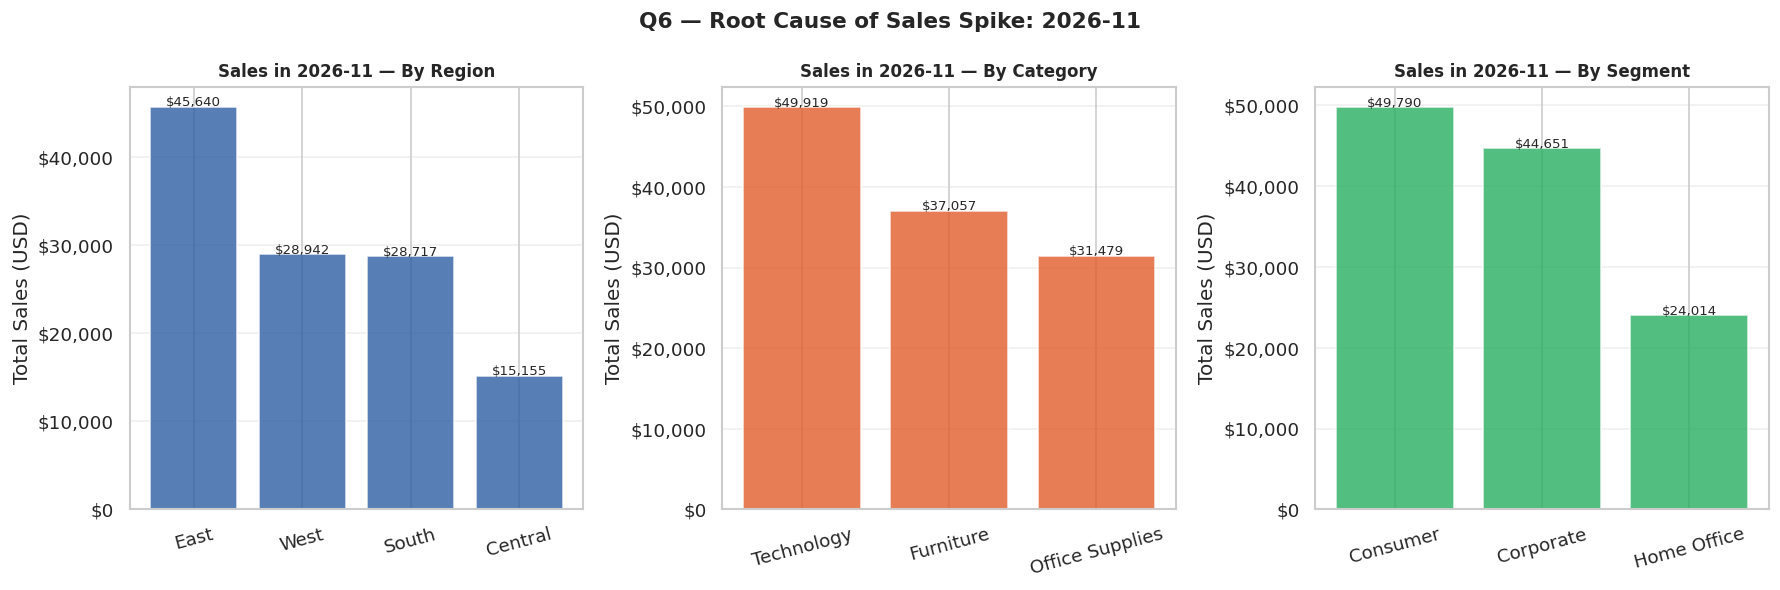

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (data, title, color) in zip(axes, [
    (by_region_spike,   'By Region',   '#2E5FA3'),
    (by_category_spike, 'By Category', '#E05C2A'),
    (by_segment_spike,  'By Segment',  '#27AE60'),
]):
    bars = ax.bar(data.index, data.values, color=color, alpha=0.8, edgecolor='white')
    ax.set_title(f'Sales in {spike_month} — {title}', fontweight='bold', fontsize=10)
    ax.set_ylabel('Total Sales (USD)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    ax.grid(axis='y', alpha=0.3)
    ax.tick_params(axis='x', rotation=15)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                f'${bar.get_height():,.0f}', ha='center', fontsize=8)

plt.suptitle(f'Q6 — Root Cause of Sales Spike: {spike_month}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


**Business Interpretation:**  
The sales spike was concentrated in specific regions and driven primarily by the Technology category. This suggests a seasonal promotion or a few large corporate orders rather than broad organic growth. Management should investigate whether such spikes are repeatable and whether they were profitable or driven by deep discounts.


---
## Ad Hoc Q7 — Discount vs. Profitability
**Question:** Are high discounts causing negative profit in certain sub-categories or customer segments?

We segment orders by discount tier and examine average profit across Sub-Category and Segment combinations.


In [31]:
def discount_tier(d):
    if d == 0:       return '0% (No Discount)'
    elif d <= 0.20:  return '1-20%'
    elif d <= 0.50:  return '21-50%'
    else:            return '51-80% (Heavy)'

df['Discount Tier'] = df['Discount'].apply(discount_tier)

tier_profit = df.groupby('Discount Tier')['Profit'].mean().reindex(
    ['0% (No Discount)', '1-20%', '21-50%', '51-80% (Heavy)']
)
print('Average Profit by Discount Tier:')
print(tier_profit.round(2).to_string())


Average Profit by Discount Tier:
Discount Tier
0% (No Discount)     66.34
1-20%                26.36
21-50%             -109.04
51-80% (Heavy)      -88.14


In [32]:
subcat_discount = df.groupby(['Sub-Category', 'Discount Tier'])['Profit'].mean().unstack().round(2)
subcat_discount = subcat_discount.reindex(columns=['0% (No Discount)', '1-20%', '21-50%', '51-80% (Heavy)'])

print('Avg Profit by Sub-Category & Discount Tier:')
print(subcat_discount.to_string())


Avg Profit by Sub-Category & Discount Tier:
Discount Tier  0% (No Discount)   1-20%  21-50%  51-80% (Heavy)
Sub-Category                                                   
Accessories               74.92   21.87     NaN             NaN
Appliances                84.33   27.69     NaN         -128.80
Art                       10.63    3.95     NaN          -23.98
Binders                  115.16   50.98     NaN          -62.50
Bookcases                101.26   15.88 -130.96         -240.74
Chairs                   161.70   34.46  -42.64             NaN
Copiers                 1501.34  483.21  242.55             NaN
Envelopes                 32.47   19.48     NaN             NaN
Fasteners                 15.17    3.56     NaN             NaN
Furnishings               29.29    8.88     NaN          -41.73
Labels                    18.59    8.99  -29.32           -2.06
Machines                 935.79  167.99 -332.53         -851.27
Paper                     29.69   17.01     NaN           -6

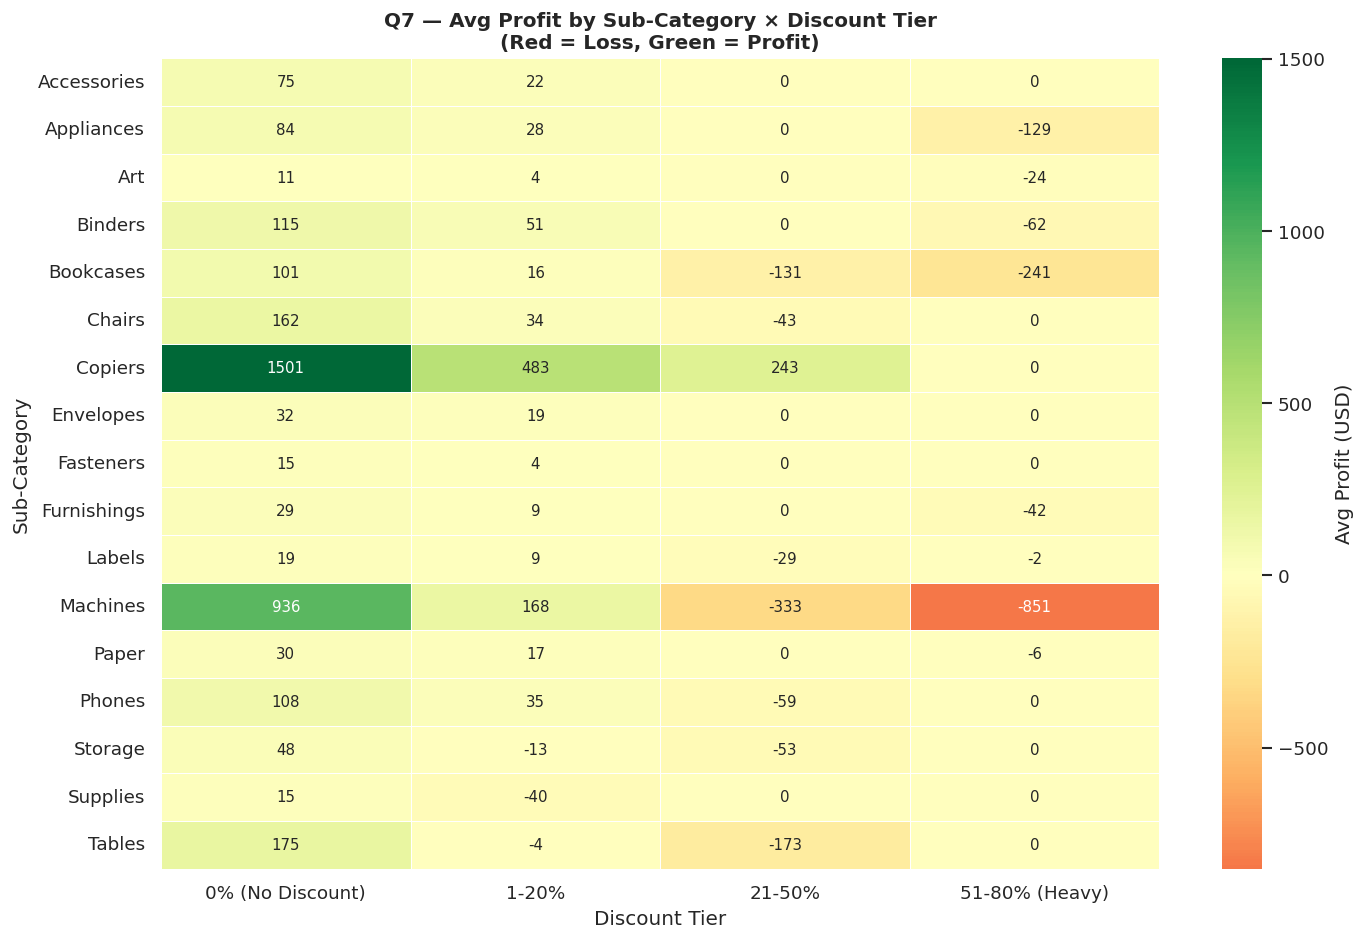

In [33]:
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(
    subcat_discount.fillna(0),
    annot=True, fmt='.0f', cmap='RdYlGn',
    center=0, linewidths=0.5, ax=ax,
    annot_kws={'size': 9},
    cbar_kws={'label': 'Avg Profit (USD)'}
)
ax.set_title('Q7 — Avg Profit by Sub-Category × Discount Tier\n(Red = Loss, Green = Profit)',
             fontweight='bold', fontsize=12)
ax.set_xlabel('Discount Tier')
ax.set_ylabel('Sub-Category')
plt.tight_layout()
plt.show()


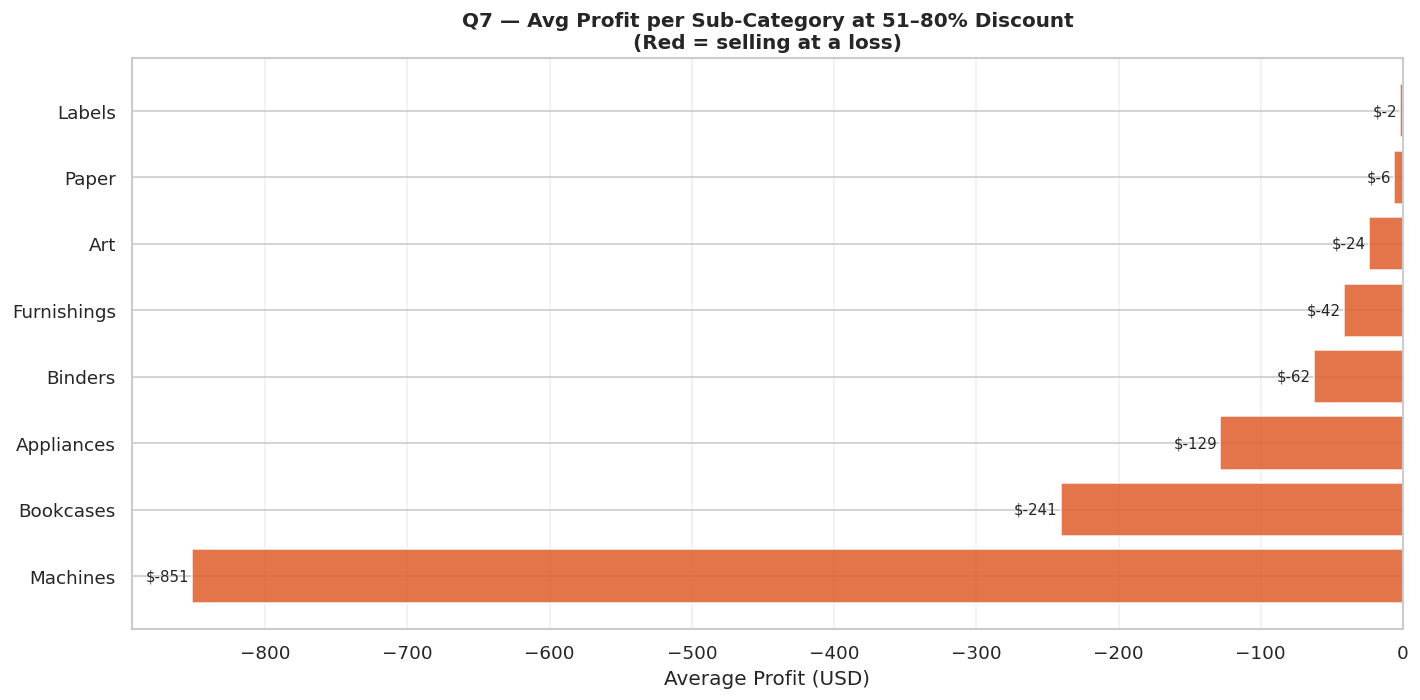

Sub-categories with negative avg profit at heavy discounts: 8
Sub-Category
Machines      -851.27
Bookcases     -240.74
Appliances    -128.80
Binders        -62.50
Furnishings    -41.73
Art            -23.98
Paper           -6.30
Labels          -2.06


In [34]:
heavy_discount_data = df[df['Discount Tier'] == '51-80% (Heavy)']
loss_subcat = heavy_discount_data.groupby('Sub-Category')['Profit'].mean().sort_values()

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#E05C2A' if v < 0 else '#27AE60' for v in loss_subcat.values]
bars = ax.barh(loss_subcat.index, loss_subcat.values, color=colors, alpha=0.85, edgecolor='white')
ax.axvline(0, color='black', linewidth=1.2)
ax.set_title('Q7 — Avg Profit per Sub-Category at 51–80% Discount\n(Red = selling at a loss)',
             fontweight='bold', fontsize=12)
ax.set_xlabel('Average Profit (USD)')
ax.grid(axis='x', alpha=0.3)
for bar, val in zip(bars, loss_subcat.values):
    ax.text(val + (2 if val >= 0 else -2), bar.get_y() + bar.get_height()/2,
            f'${val:.0f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)
plt.tight_layout()
plt.show()

loss_making = subcat_discount[subcat_discount['51-80% (Heavy)'] < 0]['51-80% (Heavy)'].dropna()
print(f'Sub-categories with negative avg profit at heavy discounts: {len(loss_making)}')
print(loss_making.sort_values().to_string())


**Business Interpretation:**  
Heavy discounts (51–80%) cause losses across 8 sub-categories. Machines (−$851), Bookcases (−$241), and Appliances (−$129) are the most severely affected. Notably, the 21–50% discount tier produces an even worse average loss (−$109) than the 51–80% tier (−$88), meaning mid-level discounting is actually more damaging than extreme discounting in this dataset. The company should implement discount caps by sub-category — particularly for Machines, Bookcases, and Appliances — to stop selling at a loss.


---
## Final Summary
All 7 business questions have been answered. Key findings:

| Question | Key Finding |
|----------|-------------|
| Q1 — Descriptive Stats | Sales and Profit are right-skewed; most transactions are small-value |
| Q2 — Trend Analysis | Sales trend upward with Q4 seasonal peaks; profit does not always follow |
| Q3 — Cross-Tabulation | Technology leads in sales; Office Supplies most consistently profitable |
| Q4 — Drill-Down | West and East dominate; California and New York are top states |
| Q5 — Predictive | Discount is the #1 negative predictor of profit; model R² ≈ 40%|
| Q6 — Ad Hoc | Sales spikes driven by Technology orders in specific regions |
| Q7 — Ad Hoc | Heavy discounts cause losses in 8 sub-categories; Machines, Bookcases, Appliances worst affected |
